# Phase 4 — Real-event change detection and acquisition-sequence audit

This notebook screens candidate Canadian flood events, selects a reproducible case, and tests whether RCM-derived NRCan EGS products can detect, compare, and validate short-term mapped open-water change.

The seven Lower Fraser records are treated as **discrete, independently processed acquisitions**. They are not a daily hydrograph, a continuous interpolation, or a measured flood peak. The first product supplies a fixed semantic permanent-water reference for spatial accounting; it is not described as an independently observed pre-event hydrologic normal.

## 1. Purpose

In [68]:
from __future__ import annotations

from collections import deque
from pathlib import Path
from urllib.parse import urlencode
from urllib.request import Request, urlopen, urlretrieve
from zipfile import ZipFile
import json
import tempfile
import xml.etree.ElementTree as ET
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import rasterio
from IPython.display import Markdown, display
from pyproj import Transformer
from pystac_client import Client
from rasterio.features import geometry_mask, rasterize, shapes
from rasterio.transform import array_bounds, from_origin
from rasterio.warp import Resampling, reproject, transform_geom
from rasterio.windows import Window, from_bounds
from shapely.geometry import LineString, box, mapping, shape
from shapely.ops import transform as shapely_transform, unary_union

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})
warnings.filterwarnings("ignore", message="Could not parse bucket/account from href.*", category=UserWarning)

RCM_STAC = "https://www.eodms-sgdot.nrcan-rncan.gc.ca/search"
EARTH_SEARCH = "https://earth-search.aws.element84.com/v1"
EGS_BASE = "https://data.eodms-sgdot.nrcan-rncan.gc.ca/public/EGS/2025/Flood/CAN/BC"
WORKING_CRS = "EPSG:32610"
AOI_BOUNDS_UTM = (563960, 5443240, 569960, 5449240)
to_wgs84 = Transformer.from_crs(WORKING_CRS, "EPSG:4326", always_xy=True).transform
AOI_WGS84 = shapely_transform(to_wgs84, box(*AOI_BOUNDS_UTM))
AOI_BBOX = AOI_WGS84.bounds

RR_THRESHOLD_DB = -17.314
GRID_METRES = 1000
CONTROL_CV_PCT = 3.20
CONTROL_MAX_DEVIATION_PCT = 5.88
CONTROL_S2_AREA_DIFFERENCE_PCT = 4.88
PIXEL_SIZE = 20
PIXEL_AREA_HA = PIXEL_SIZE * PIXEL_SIZE / 10_000

print("Working CRS:", WORKING_CRS)
print("AOI WGS84 bounds:", tuple(round(value, 6) for value in AOI_BBOX))
print("Fixed analysis pixel:", f"{PIXEL_SIZE} m × {PIXEL_SIZE} m")

Working CRS: EPSG:32610
AOI WGS84 bounds: (-122.123101, 49.138003, -122.039809, 49.192623)
Fixed analysis pixel: 20 m × 20 m


## 2. Phase 3 constraints inherited

- CEOS-ARD validity means `data_mask == 1`; all other codes remain unknown.
- Platform, orbit, mode, polarization, CRS, resolution, transform, local incidence angle, and gamma/sigma ratio remain visible diagnostics.
- The fixed `RR < -17.314 dB` rule is used only for the same CEOS-ARD radiometric representation as Phase 3. It is **not** transferred to the EGS vector product or Level-1 GRD.
- Continuous ARD layers are bilinearly reprojected to the fixed 20 m working grid. Categorical masks use nearest-neighbour; categorical optical results use mode aggregation.
- Phase 2 values (CV 3.20%, maximum deviation 5.88%, and same-day RCM/Sentinel area difference 4.88%) are empirical feasibility benchmarks, not universal confidence limits.

## 3. Candidate-event definition

In [69]:
candidate_table = pd.DataFrame([
    {
        "candidate": "Nova Scotia flood, 21–23 Jul 2023",
        "official impact evidence": "Extreme rainfall; public-safety and road/bridge impacts",
        "RCM feasibility": "Rejected: no intersecting public RCM-ARD or Level-1 records in the tested impact AOIs/window",
        "independent support": "Official reports available",
        "decision": "Reject — event-period RCM chain absent",
    },
    {
        "candidate": "Central Ottawa River spring freshet, May 2025",
        "official impact evidence": "Official flood products and water-level reporting",
        "RCM feasibility": "RCM1 same-platform/orbit sequence available",
        "independent support": "NRCan May 2/14 flood polygons",
        "decision": "Reject — no grid rose above 5.88 pp contextual comparison; RCM gain vs reference IoU = 0",
    },
    {
        "candidate": "Fraser Valley / Lower Fraser flood, Dec 2025",
        "official impact evidence": "Flood warning, evacuations, road closures, property impacts",
        "RCM feasibility": "Seven open EGS RCM products + public CEOS-ARD before/after brackets",
        "independent support": "Sentinel-2 + official emergency reporting",
        "decision": "SELECT",
    },
])
display(candidate_table)

,candidate,official impact evidence,RCM feasibility,independent support,decision
0,"Nova Scotia flood, 21–23 Jul 2023",Extreme rainfall; public-safety and road/bridge impacts,Rejected: no intersecting public RCM-ARD or Level-1 records in the tested impact AOIs/...,Official reports available,Reject — event-period RCM chain absent
1,"Central Ottawa River spring freshet, May 2025",Official flood products and water-level reporting,RCM1 same-platform/orbit sequence available,NRCan May 2/14 flood polygons,Reject — no grid rose above 5.88 pp contextual comparison; RCM gain vs reference IoU = 0
2,"Fraser Valley / Lower Fraser flood, Dec 2025","Flood warning, evacuations, road closures, property impacts",Seven open EGS RCM products + public CEOS-ARD before/after brackets,Sentinel-2 + official emergency reporting,SELECT


## 4. Official event evidence

Official reporting establishes the event context, not pixel-level ground truth:

- [EmergencyInfoBC flood warning, updated 10 Dec 2025](https://www.emergencyinfobc.gov.bc.ca/event/floodwatch-fraservalley-09122025/) names the Sumas River and Lower Fraser tributaries including the Chilliwack River, plus Abbotsford, Chilliwack, and Hope.
- [City of Abbotsford, 23 Dec 2025](https://www.abbotsford.ca/council/your-council-community/blog/abbotsford-shows-resilience-and-compassion-face-disaster) reports evacuation orders/alerts, property impacts, livestock loss, and a Highway 1 closure elsewhere in the wider event area.
- [B.C. road update, 13 Dec 2025](https://news.gov.bc.ca/releases/2025TT0126-001250) documents floodwater affecting Highway 1 in the wider Sumas area.
- [Fraser Valley Regional District update, 20 Dec 2025](https://www.fvrd.ca/EN/meta/news/news-archives/2025/atmospheric-river-update-saturday-dec-20.html?media=contrast) describes saturated conditions and declining Chilliwack River levels.

In [70]:
official_timeline = pd.DataFrame([
    ["2025-12-09 to 10", "Fraser Valley East watch upgraded to warning", "EmergencyInfoBC / BC River Forecast Centre"],
    ["2025-12-10 to 11", "Flood response, evacuation and road impacts reported across Fraser Valley", "Provincial and local authorities"],
    ["2025-12-12 14:08 UTC", "First selected Lower Fraser EGS RCM flood product", "NRCan EGS"],
    ["2025-12-13", "Floodwater reported on Highway 1 in the wider Sumas event area", "Province of British Columbia"],
    ["2025-12-14 to 21", "Six further Lower Fraser EGS observations track recession/recovery", "NRCan EGS"],
    ["2025-12-20", "FVRD reports saturated conditions and declining Chilliwack River levels", "Fraser Valley Regional District"],
    ["2025-12-23", "Abbotsford summarizes evacuations and infrastructure/community impacts", "City of Abbotsford"],
], columns=["date / time", "event evidence", "source"])
display(official_timeline)

,date / time,event evidence,source
0,2025-12-09 to 10,Fraser Valley East watch upgraded to warning,EmergencyInfoBC / BC River Forecast Centre
1,2025-12-10 to 11,"Flood response, evacuation and road impacts reported across Fraser Valley",Provincial and local authorities
2,2025-12-12 14:08 UTC,First selected Lower Fraser EGS RCM flood product,NRCan EGS
3,2025-12-13,Floodwater reported on Highway 1 in the wider Sumas event area,Province of British Columbia
4,2025-12-14 to 21,Six further Lower Fraser EGS observations track recession/recovery,NRCan EGS
5,2025-12-20,FVRD reports saturated conditions and declining Chilliwack River levels,Fraser Valley Regional District
6,2025-12-23,Abbotsford summarizes evacuations and infrastructure/community impacts,City of Abbotsford


## 5. Event AOI selection

The fixed 6 km × 6 km UTM Zone 10N AOI was selected by intersecting all seven EGS footprints with both public CEOS-ARD bracket acquisitions, then choosing a compact, 20 m-aligned rectangle with complete EGS coverage. It lies in the Chilliwack-area Lower Fraser corridor. This is a reproducibility/coverage choice, not a claim that the AOI contains the event's worst impacts.

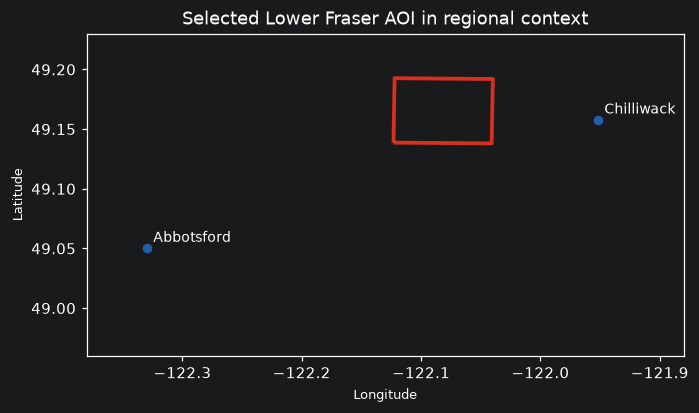

,working_bounds_utm10,wgs84_west,wgs84_south,wgs84_east,wgs84_north,nominal_area_km2
0,"(563960, 5443240, 569960, 5449240)",-122.123101,49.138003,-122.039809,49.192623,36.0


In [71]:
fig, ax = plt.subplots(figsize=(7, 6))
gpd.GeoSeries([AOI_WGS84], crs=4326).boundary.plot(ax=ax, linewidth=2.5, color="#d7301f")
places = pd.DataFrame({
    "place": ["Chilliwack", "Abbotsford", "Hope"],
    "lon": [-121.9515, -122.3295, -121.4417],
    "lat": [49.1579, 49.0504, 49.3829],
})
ax.scatter(places.lon, places.lat, color="#225ea8", s=28)
for row in places.itertuples():
    ax.annotate(row.place, (row.lon, row.lat), xytext=(4, 4), textcoords="offset points", fontsize=9)
ax.set(xlim=(-122.38, -121.88), ylim=(48.96, 49.23), xlabel="Longitude", ylabel="Latitude",
       title="Selected Lower Fraser AOI in regional context")
ax.set_aspect("equal", adjustable="box")
plt.show()

display(pd.DataFrame([{
    "working_bounds_utm10": str(AOI_BOUNDS_UTM),
    "wgs84_west": AOI_BBOX[0], "wgs84_south": AOI_BBOX[1],
    "wgs84_east": AOI_BBOX[2], "wgs84_north": AOI_BBOX[3],
    "nominal_area_km2": 36.0,
}]).round(6))

## 6. RCM Level-1 / ARD coverage screening

In [72]:
rcm_screening = pd.DataFrame([
    ["2023 Nova Scotia candidate", "2023-06-15 to 2023-08-20", "RCMImageProducts + rcm-ard", 0,
     "No intersecting acquisitions in the tested official-impact AOIs; reject"],
    ["Selected event — Level-1", "2025-12-13 to 2025-12-23", "RCMImageProducts", 8,
     "Metadata visible; full ZIP requires EODMS bearer-token authentication"],
    ["Selected event — EGS", "2025-12-12 to 2025-12-21", "NRCan EGS RCM-derived vectors", 7,
     "Anonymous public ZIP download; selected main event sequence"],
    ["Selected event — public ARD", "2025-11-08 / 2026-01-07", "rcm-ard CEOS-ARD", 4,
     "Anonymous public COG ranges; two adjacent records mosaicked per date"],
], columns=["case / route", "window", "product", "records", "access / decision"])
display(rcm_screening)

,case / route,window,product,records,access / decision
0,2023 Nova Scotia candidate,2023-06-15 to 2023-08-20,RCMImageProducts + rcm-ard,0,No intersecting acquisitions in the tested official-impact AOIs; reject
1,Selected event — Level-1,2025-12-13 to 2025-12-23,RCMImageProducts,8,Metadata visible; full ZIP requires EODMS bearer-token authentication
2,Selected event — EGS,2025-12-12 to 2025-12-21,NRCan EGS RCM-derived vectors,7,Anonymous public ZIP download; selected main event sequence
3,Selected event — public ARD,2025-11-08 / 2026-01-07,rcm-ard CEOS-ARD,4,Anonymous public COG ranges; two adjacent records mosaicked per date


## 7. Sentinel-1 / Sentinel-2 coverage screening

In [73]:
earth = Client.open(EARTH_SEARCH)
s1_items = list(earth.search(
    collections=["sentinel-1-grd"], bbox=AOI_BBOX,
    datetime="2025-12-01T00:00:00Z/2025-12-28T23:59:59Z", max_items=None,
).items())
s2_items = list(earth.search(
    collections=["sentinel-2-c1-l2a"], bbox=AOI_BBOX,
    datetime="2025-12-01T00:00:00Z/2025-12-28T23:59:59Z", max_items=None,
).items())

support_screening = pd.DataFrame([
    ["Sentinel-1 GRD", len(s1_items), "IW VV/VH; 11 metadata records in tested window",
     "Level-1 measurement assets are requester-pays; not forced into quantitative analysis"],
    ["Sentinel-2 C1 L2A", len(s2_items), "B03 green, B08 NIR, SCL",
     "Public COGs; 2 Dec pre-event and 27 Dec recovery observations selected"],
    ["NRCan EGS flood extent", 7, "RCM-derived permanent-water and open-water-flood vector classes",
     "Public official products; main event sequence"],
])
support_screening.columns = ["source", "records", "relevant data", "access / use"]
display(support_screening)

,source,records,relevant data,access / use
0,Sentinel-1 GRD,11,IW VV/VH; 11 metadata records in tested window,Level-1 measurement assets are requester-pays; not forced into quantitative analysis
1,Sentinel-2 C1 L2A,14,"B03 green, B08 NIR, SCL",Public COGs; 2 Dec pre-event and 27 Dec recovery observations selected
2,NRCan EGS flood extent,7,RCM-derived permanent-water and open-water-flood vector classes,Public official products; main event sequence


## 8. Independent flood/event reference discovery

NRCan EGS products are authoritative operational products but are themselves RCM-derived, so they are not treated as an independent sensor validation of RCM. Sentinel-2 is the independent EO check; emergency reporting supplies historical/contextual validation; OSM supplies contextual infrastructure geometry.

In [74]:
reference_table = pd.DataFrame([
    ["Sentinel-2 L2A", "Independent optical water signal", "Earth Search STAC", "Open COG access"],
    ["EmergencyInfoBC / BC RFC", "Official event timing and affected-area context", "Government of B.C.", "Public web"],
    ["Local/provincial reports", "Evacuation and road-impact context", "Abbotsford / B.C. / FVRD", "Public web"],
    ["OpenStreetMap roads", "Preliminary infrastructure overlay", "OpenStreetMap contributors", "Overpass API; ODbL"],
], columns=["dataset", "role", "authority", "access"])
display(reference_table)

,dataset,role,authority,access
0,Sentinel-2 L2A,Independent optical water signal,Earth Search STAC,Open COG access
1,EmergencyInfoBC / BC RFC,Official event timing and affected-area context,Government of B.C.,Public web
2,Local/provincial reports,Evacuation and road-impact context,Abbotsford / B.C. / FVRD,Public web
3,OpenStreetMap roads,Preliminary infrastructure overlay,OpenStreetMap contributors,Overpass API; ODbL


## 9. Final case selection decision

**Decision:** select the December 2025 Fraser Valley / Lower Fraser flood, with a Chilliwack-area AOI. It is the first screened case with (1) a documented public-safety event, (2) multiple publicly downloadable RCM-derived event observations, (3) real public RCM observations bracketing the event, (4) independent optical support, and (5) infrastructure geometry. The July 2023 Nova Scotia preference was not forced after its tested AOIs failed RCM coverage screening.

In [75]:
selection_matrix = pd.DataFrame({
    "criterion": ["Documented event", "Pre RCM", "Event-near RCM", "Post RCM", "Independent EO/reference", "Infrastructure layer"],
    "result": ["Pass", "Pass — 8 Nov ARD", "Pass — 12–21 Dec EGS", "Pass — 7 Jan ARD", "Pass — Sentinel-2 + official reports", "Pass — OSM roads"],
})
display(selection_matrix)

,criterion,result
0,Documented event,Pass
1,Pre RCM,Pass — 8 Nov ARD
2,Event-near RCM,Pass — 12–21 Dec EGS
3,Post RCM,Pass — 7 Jan ARD
4,Independent EO/reference,Pass — Sentinel-2 + official reports
5,Infrastructure layer,Pass — OSM roads


## 10. Before / during / after acquisition selection

In [76]:
EGS_PRODUCTS = {
    "OBS01": "Flood_CAN_BC_LowerFraser_20251212_140824.zip",
    "OBS02": "Flood_CAN_BC_LowerFraser_20251214_142423.zip",
    "OBS03": "Flood_CAN_BC_LowerFraser_20251215_015037.zip",
    "OBS04": "Flood_CAN_BC_LowerFraser_20251216_140835.zip",
    "OBS05": "Flood_CAN_BC_LowerFraser_20251217_141634.zip",
    "OBS06": "Flood_CAN_BC_LowerFraser_20251219_015014.zip",
    "OBS07": "Flood_CAN_BC_LowerFraser_20251221_141646.zip",
}
OBSERVATION_CONTEXT = {
    "OBS01": "initial selected observation",
    "OBS02": "intervening low mapped extent",
    "OBS03": "secondary-pulse context",
    "OBS04": "later elevated observation",
    "OBS05": "later elevated observation",
    "OBS06": "lower endpoint observation",
    "OBS07": "lower endpoint observation",
}
S2_IDS = {
    "pre-event": "S2B_T10UEV_20251202T190649_L2A",
    "recovery-period": "S2C_T10UEV_20251227T191058_L2A",
}

CACHE_ROOT = Path(tempfile.gettempdir()) / "earth-in-motion-phase4-egs"
CACHE_ROOT.mkdir(parents=True, exist_ok=True)
egs_folders = {}
for observation_id, filename in EGS_PRODUCTS.items():
    folder = CACHE_ROOT / filename.removesuffix(".zip")
    if not next(folder.glob("Flood_*.shp"), None):
        folder.mkdir(parents=True, exist_ok=True)
        archive = CACHE_ROOT / filename
        if not archive.exists():
            print("Downloading", filename)
            urlretrieve(f"{EGS_BASE}/{filename}", archive)
        with ZipFile(archive) as zipped:
            zipped.extractall(folder)
    egs_folders[observation_id] = folder

acquisition_plan = pd.DataFrame([
    ["pre-event CEOS-ARD diagnostic", "2025-11-08 01:42:39 UTC", "RCM3 public CEOS-ARD", "Actual RCM observation; not semantically interchangeable with EGS"],
    ["OBS01", "2025-12-12 14:08:24 UTC", "RCM-1 / NRCan EGS", "Initial selected observation; not labelled as event peak"],
    ["OBS02–OBS07", "2025-12-14 to 2025-12-21", "RCM-1/2/3 / NRCan EGS", "Six discrete observations with mixed acquisition/product characteristics"],
    ["post-event CEOS-ARD diagnostic", "2026-01-07 01:42:38 UTC", "RCM3 public CEOS-ARD", "Actual RCM observation on matching relative orbit"],
    ["optical recovery check", "2025-12-27 19:11:08 UTC", "Sentinel-2C L2A", "6.2 days after OBS07"],
], columns=["role", "timestamp / window", "source", "interpretation"])
display(acquisition_plan)

,role,timestamp / window,source,interpretation
0,pre-event CEOS-ARD diagnostic,2025-11-08 01:42:39 UTC,RCM3 public CEOS-ARD,Actual RCM observation; not semantically interchangeable with EGS
1,OBS01,2025-12-12 14:08:24 UTC,RCM-1 / NRCan EGS,Initial selected observation; not labelled as event peak
2,OBS02–OBS07,2025-12-14 to 2025-12-21,RCM-1/2/3 / NRCan EGS,Six discrete observations with mixed acquisition/product characteristics
3,post-event CEOS-ARD diagnostic,2026-01-07 01:42:38 UTC,RCM3 public CEOS-ARD,Actual RCM observation on matching relative orbit
4,optical recovery check,2025-12-27 19:11:08 UTC,Sentinel-2C L2A,6.2 days after OBS07


## 11. RCM preprocessing for the selected event

The EGS vectors are categorical. They are clipped, reprojected, and rasterized directly to a fixed EPSG:32610 20 m grid using center-pixel semantics. Class 1 is permanent water and class 2 is open-water flood. EGS footprint polygons define validity. Public CEOS-ARD continuous RR/LIA/gamma-sigma layers are bilinearly reprojected; `data_mask` uses nearest-neighbour and only code 1 is accepted. Exact source transforms, CRS, resolution and platform metadata are retained below.

In [77]:
TARGET_TRANSFORM = from_origin(AOI_BOUNDS_UTM[0], AOI_BOUNDS_UTM[3], PIXEL_SIZE, PIXEL_SIZE)
TARGET_SHAPE = (
    int((AOI_BOUNDS_UTM[3] - AOI_BOUNDS_UTM[1]) / PIXEL_SIZE),
    int((AOI_BOUNDS_UTM[2] - AOI_BOUNDS_UTM[0]) / PIXEL_SIZE),
)
TARGET_BOUNDS = array_bounds(*TARGET_SHAPE, TARGET_TRANSFORM)
AOI_UTM = box(*AOI_BOUNDS_UTM)
AOI_MASK = geometry_mask([mapping(AOI_UTM)], out_shape=TARGET_SHAPE,
                         transform=TARGET_TRANSFORM, invert=True)

def rasterize_geometry(geometry, value=1):
    if geometry is None or geometry.is_empty:
        return np.zeros(TARGET_SHAPE, dtype=np.uint8)
    return rasterize(
        [(mapping(geometry), value)], out_shape=TARGET_SHAPE,
        transform=TARGET_TRANSFORM, fill=0, dtype=np.uint8,
        all_touched=False,
    )

def seeded_components(binary, seed):
    rows, cols = binary.shape
    visited = np.zeros_like(binary, dtype=bool)
    selected = np.zeros_like(binary, dtype=bool)
    for start_row, start_col in np.argwhere(binary & seed):
        start_row, start_col = int(start_row), int(start_col)
        if visited[start_row, start_col]:
            continue
        queue = deque([(start_row, start_col)])
        visited[start_row, start_col] = True
        component = []
        while queue:
            row, col = queue.popleft()
            component.append((row, col))
            for dr in (-1, 0, 1):
                for dc in (-1, 0, 1):
                    if dr == dc == 0:
                        continue
                    rr, cc = row + dr, col + dc
                    if 0 <= rr < rows and 0 <= cc < cols and binary[rr, cc] and not visited[rr, cc]:
                        visited[rr, cc] = True
                        queue.append((rr, cc))
        for row, col in component:
            selected[row, col] = True
    return selected

def read_remote_window(item, key):
    with rasterio.Env(GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR", CPL_VSIL_CURL_ALLOWED_EXTENSIONS=".tif"):
        with rasterio.open(item.assets[key].href) as src:
            source_geom = transform_geom("EPSG:4326", src.crs, mapping(AOI_WGS84))
            requested = from_bounds(*shape(source_geom).bounds, transform=src.transform).round_offsets().round_lengths()
            try:
                window = requested.intersection(Window(0, 0, src.width, src.height))
            except rasterio.errors.WindowError:
                return None
            return {
                "array": src.read(1, window=window, masked=True),
                "transform": src.window_transform(window), "crs": str(src.crs),
                "nodata": src.nodata, "res": tuple(src.res),
                "source_transform": tuple(src.transform), "source_shape": (src.height, src.width),
            }

def project_asset(source, resampling, dst_nodata, dtype):
    destination = np.full(TARGET_SHAPE, dst_nodata, dtype=dtype)
    reproject(
        source=source["array"].filled(source["nodata"] if source["nodata"] is not None else dst_nodata),
        destination=destination, src_transform=source["transform"], src_crs=source["crs"],
        src_nodata=source["nodata"], dst_transform=TARGET_TRANSFORM, dst_crs=WORKING_CRS,
        dst_nodata=dst_nodata, resampling=resampling,
    )
    return destination

def swath_field(filename, field):
    import re
    patterns = {
        "radiometry": r"_GRD_(Gamma|Sigma)_",
        "channel": r"_(HH|HV|VV|VH)\.tif$",
    }
    match = re.search(patterns[field], filename)
    return match.group(1) if match else None

egs_scenes, egs_rows = {}, []
for observation_id, folder in egs_folders.items():
    flood = gpd.read_file(next(folder.glob("Flood_*.shp"))).clip(AOI_WGS84).to_crs(WORKING_CRS)
    footprint = gpd.read_file(next(folder.glob("Footprint_*.shp"))).clip(AOI_WGS84).to_crs(WORKING_CRS)
    config = ET.parse(next(folder.glob("Config_*.xml"))).getroot()
    metadata = {child.tag: (child.text or "").strip() for child in config}
    permanent_geom = flood.loc[flood["class"].eq(1)].geometry.union_all()
    flood_geom = flood.loc[flood["class"].eq(2)].geometry.union_all()
    valid = rasterize_geometry(footprint.geometry.union_all()).astype(bool) & AOI_MASK
    permanent = rasterize_geometry(permanent_geom).astype(bool) & valid
    flood_mask = rasterize_geometry(flood_geom).astype(bool) & valid
    egs_scenes[observation_id] = {
        "permanent": permanent, "flood": flood_mask, "valid": valid,
        "metadata": metadata, "flood_gdf": flood, "footprint_gdf": footprint,
    }
    beam = metadata["beam"]
    comparability_level = {
        "5M22": "high within 5M22 pair",
        "16M16": "high within 16M16 pair",
        "SC30MB": "limited: radiometry/channel differ within pair",
    }.get(beam, "low: no same-beam comparison")
    egs_rows.append({
        "observation_id": observation_id,
        "timestamp_utc": pd.Timestamp(f"{metadata['dateUTC']}T{metadata['timeUTC']}Z"),
        "context_label": OBSERVATION_CONTEXT[observation_id],
        "platform": metadata["sensorName"], "beam_mode": beam,
        "source_resolution_m": float(metadata["resolution"]),
        "orbit_direction": metadata["orbitDirection"], "relative_orbit": pd.NA,
        "polarization_metadata": metadata["polarization"],
        "swath_radiometry": swath_field(metadata["swathFileName"], "radiometry"),
        "classifier_channel": swath_field(metadata["swathFileName"], "channel"),
        "product_type": metadata["productType"], "product_version": metadata["version"],
        "confidence": metadata["confidenceLevelEN"], "valid_pixels": int(valid.sum()),
        "valid_pct": 100 * valid.sum() / AOI_MASK.sum(),
        "raw_permanent_water_ha": permanent.sum() * PIXEL_AREA_HA,
        "egs_open_water_flood_ha": flood_mask.sum() * PIXEL_AREA_HA,
        "comparability_group": beam, "comparability_level": comparability_level,
        "source_product": EGS_PRODUCTS[observation_id],
    })

egs_df = pd.DataFrame(egs_rows).sort_values("timestamp_utc").reset_index(drop=True)
all_egs_valid = np.logical_and.reduce([scene["valid"] for scene in egs_scenes.values()])
fixed_reference = egs_scenes["OBS01"]["permanent"] & all_egs_valid
fixed_reference_ha = fixed_reference.sum() * PIXEL_AREA_HA
egs_df["fixed_reference_water_ha"] = fixed_reference_ha
egs_df["fixed_reference_total_water_ha"] = fixed_reference_ha + egs_df["egs_open_water_flood_ha"]
water_masks = {key: fixed_reference | (scene["flood"] & all_egs_valid) for key, scene in egs_scenes.items()}
pre_water = fixed_reference
event_water = water_masks["OBS01"]
post_water = water_masks["OBS07"]
event_gain = all_egs_valid & ~pre_water & event_water
event_to_post_loss = all_egs_valid & event_water & ~post_water
event_to_post_gain = all_egs_valid & ~event_water & post_water

display(egs_df)
print(f"Common valid EGS cells: {all_egs_valid.sum():,} / {AOI_MASK.sum():,} ({all_egs_valid.mean()*100:.1f}%)")
print("Raw class-1 values are retained for QA; all comparable totals use the fixed OBS01 reference:", fixed_reference_ha)

,observation_id,timestamp_utc,context_label,platform,beam_mode,source_resolution_m,orbit_direction,relative_orbit,polarization_metadata,swath_radiometry,classifier_channel,product_type,product_version,confidence,valid_pixels,valid_pct,raw_permanent_water_ha,egs_open_water_flood_ha,comparability_group,comparability_level,source_product,fixed_reference_water_ha,fixed_reference_total_water_ha
0,OBS01,2025-12-12 14:08:24+00:00,initial selected observation,RCM-1,5M22,5.0,DSC,<NA>,HH-HV,Gamma,HH,Flood,1.0,Moderate,90000,100.0,971.88,54.92,5M22,high within 5M22 pair,Flood_CAN_BC_LowerFraser_20251212_140824.zip,971.88,1026.80
1,OBS02,2025-12-14 14:24:23+00:00,intervening low mapped extent,RCM-1,16M9,16.0,DSC,<NA>,HH-HV,Gamma,HH,Flood,1.0,Moderate,90000,100.0,971.88,20.60,16M9,low: no same-beam comparison,Flood_CAN_BC_LowerFraser_20251214_142423.zip,971.88,992.48
2,OBS03,2025-12-15 01:50:37+00:00,secondary-pulse context,RCM-3,SC30MB,30.0,ASC,<NA>,HH-HV,Gamma,HH,Flood,1.0,Moderate,90000,100.0,971.88,50.72,SC30MB,limited: radiometry/channel differ within pair,Flood_CAN_BC_LowerFraser_20251215_015037.zip,971.88,1022.60
3,OBS04,2025-12-16 14:08:35+00:00,later elevated observation,RCM-2,5M22,5.0,DSC,<NA>,HH-HV,Gamma,HH,Flood,1.0,Moderate,90000,100.0,973.28,36.60,5M22,high within 5M22 pair,Flood_CAN_BC_LowerFraser_20251216_140835.zip,971.88,1008.48
4,OBS05,2025-12-17 14:16:34+00:00,later elevated observation,RCM-2,16M16,16.0,DSC,<NA>,HH-HV,Sigma,HH,Flood,1.0,Moderate,90000,100.0,973.28,37.28,16M16,high within 16M16 pair,Flood_CAN_BC_LowerFraser_20251217_141634.zip,971.88,1009.16
5,OBS06,2025-12-19 01:50:14+00:00,lower endpoint observation,RCM-1,SC30MB,30.0,ASC,<NA>,HH-HV,Sigma,HV,Flood,1.0,Moderate,90000,100.0,973.28,28.96,SC30MB,limited: radiometry/channel differ within pair,Flood_CAN_BC_LowerFraser_20251219_015014.zip,971.88,1000.84
6,OBS07,2025-12-21 14:16:46+00:00,lower endpoint observation,RCM-3,16M16,16.0,DSC,<NA>,HH-HV,Sigma,HH,Flood,1.0,Moderate,90000,100.0,973.28,21.64,16M16,high within 16M16 pair,Flood_CAN_BC_LowerFraser_20251221_141646.zip,971.88,993.52


Common valid EGS cells: 90,000 / 90,000 (100.0%)
Raw class-1 values are retained for QA; all comparable totals use the fixed OBS01 reference: 971.88


In [78]:
ard_items = list(Client.open(RCM_STAC).search(
    collections=["rcm-ard"], bbox=(-122.6, 48.9, -121.8, 49.5),
    datetime="2025-11-01T00:00:00Z/2026-01-12T23:59:59Z", max_items=None,
).items())

ard_scenes = {}
ard_rows = []
for label, date in [("pre-event", "2025-11-08"), ("post-event", "2026-01-07")]:
    group = [item for item in ard_items if item.properties["datetime"].startswith(date)]
    rr_sum = np.zeros(TARGET_SHAPE, dtype=float)
    lia_sum = np.zeros(TARGET_SHAPE, dtype=float)
    ratio_sum = np.zeros(TARGET_SHAPE, dtype=float)
    count = np.zeros(TARGET_SHAPE, dtype=np.uint8)
    source_rows = []
    item_ids = []
    for item in group:
        rr_source = read_remote_window(item, "rr")
        if rr_source is None:
            continue
        mask_source = read_remote_window(item, "data_mask")
        lia_source = read_remote_window(item, "local_inc_angle")
        ratio_source = read_remote_window(item, "gamma_to_sigma_ratio")
        item_ids.append(item.id)
        source_rows.append((item.id, rr_source["crs"], rr_source["res"], rr_source["source_transform"]))
        rr = project_asset(rr_source, Resampling.bilinear, np.nan, float)
        data_mask = project_asset(mask_source, Resampling.nearest, 0, np.uint8)
        lia = project_asset(lia_source, Resampling.bilinear, np.nan, float)
        ratio = project_asset(ratio_source, Resampling.bilinear, np.nan, float)
        valid = AOI_MASK & (data_mask == 1) & np.isfinite(rr) & (rr > 0)
        rr_sum[valid] += rr[valid]
        lia_sum[valid] += lia[valid]
        ratio_sum[valid] += ratio[valid]
        count[valid] += 1
    valid = count > 0
    rr_linear = np.full(TARGET_SHAPE, np.nan)
    lia = np.full(TARGET_SHAPE, np.nan)
    ratio = np.full(TARGET_SHAPE, np.nan)
    rr_linear[valid] = rr_sum[valid] / count[valid]
    lia[valid] = lia_sum[valid] / count[valid]
    ratio[valid] = ratio_sum[valid] / count[valid]
    rr_db = np.full(TARGET_SHAPE, np.nan)
    rr_db[valid] = 10 * np.log10(rr_linear[valid])
    # Seed this representation-specific ARD diagnostic with the explicit OBS01 class-1 reference.
    water = seeded_components(valid & (rr_db < RR_THRESHOLD_DB), fixed_reference)
    ard_scenes[label] = {"valid": valid, "rr_db": rr_db, "water": water,
                         "lia": lia, "ratio": ratio, "items": group}
    props = group[0].properties
    ard_rows.append({
        "label": label, "datetime_utc": pd.Timestamp(props["datetime"]),
        "platform": props.get("title", "").split("_")[0],
        "relative_orbit": props.get("sat:relative_orbit"), "orbit_state": props.get("sat:orbit_state"),
        "mode": props.get("sar:instrument_mode"),
        "polarizations": "/".join(props.get("sar:polarizations", [])),
        "records_mosaicked": len(item_ids), "item_ids": ", ".join(item_ids),
        "source_crs": ", ".join(sorted({row[1] for row in source_rows})),
        "source_resolution_m": ", ".join(sorted({str(row[2]) for row in source_rows})),
        "valid_pixels": int(valid.sum()), "valid_pct": 100 * valid.sum() / AOI_MASK.sum(),
        "lia_mean_deg": np.nanmean(lia[valid]), "gamma_sigma_mean": np.nanmean(ratio[valid]),
        "fixed_threshold_water_ha": water.sum() * PIXEL_AREA_HA,
    })

ard_df = pd.DataFrame(ard_rows)
ard_common = ard_scenes["pre-event"]["valid"] & ard_scenes["post-event"]["valid"]
ard_pre_area = (ard_scenes["pre-event"]["water"] & ard_common).sum() * PIXEL_AREA_HA
ard_post_area = (ard_scenes["post-event"]["water"] & ard_common).sum() * PIXEL_AREA_HA
display(ard_df)
print(f"ARD common-valid pre/post areas: {ard_pre_area:.2f} ha / {ard_post_area:.2f} ha")
print("The fixed threshold is used only here, on the matching CEOS-ARD representation.")

,label,datetime_utc,platform,relative_orbit,orbit_state,mode,polarizations,records_mosaicked,item_ids,source_crs,source_resolution_m,valid_pixels,valid_pct,lia_mean_deg,gamma_sigma_mean,fixed_threshold_water_ha
0,pre-event,2025-11-08 01:42:39.988460,RCM3,166,Ascending,Medium Resolution 30m,CH/CV/XC,2,"cc0e02e8-8d8e-439f-ae81-9173f232fb89, fd241276-682d-4a1b-872c-aaedd88c4a05",EPSG:32610,"(20.0, 20.0)",86632,96.257778,18.634866,0.943497,756.88
1,post-event,2026-01-07 01:42:38.060019,RCM3,166,Ascending,Medium Resolution 30m,CH/CV/XC,2,"16ebbe33-a94e-49b5-b8e8-3bac29612416, b5e0a452-3c67-4a0c-97c6-14d51a9e3c55",EPSG:32610,"(20.0, 20.0)",86229,95.810000,18.614722,0.943711,727.28


ARD common-valid pre/post areas: 756.84 ha / 727.24 ha
The fixed threshold is used only here, on the matching CEOS-ARD representation.


## 12. Supporting EO preprocessing

Sentinel-2 surface reflectance is computed from the asset scale/offset. NDWI uses B03 and B08 at 10 m. SCL values 0, 1, 3, 8, 9, 10 and 11 are excluded; SCL is moved to the 10 m spectral grid using nearest-neighbour. The final water/non-water/unknown class is aggregated to the fixed 20 m grid using mode. No per-date threshold fitting is performed (`NDWI > 0`).

In [79]:
s2_lookup = {item.id: item for item in s2_items}
s2_scenes = {}
s2_rows = []
for label, item_id in S2_IDS.items():
    item = s2_lookup[item_id]
    green_source = read_remote_window(item, "green")
    nir_source = read_remote_window(item, "nir")
    scl_source = read_remote_window(item, "scl")
    green = green_source["array"].astype(float).filled(np.nan)
    nir = nir_source["array"].astype(float).filled(np.nan)
    band_meta = item.assets["green"].extra_fields["raster:bands"][0]
    scale, offset = float(band_meta["scale"]), float(band_meta["offset"])
    green = green * scale + offset
    nir = nir * scale + offset
    ndwi = (green - nir) / (green + nir)
    scl_10m = np.full(green.shape, 255, dtype=np.uint8)
    reproject(
        source=scl_source["array"].filled(0).astype(np.uint8), destination=scl_10m,
        src_transform=scl_source["transform"], src_crs=scl_source["crs"], src_nodata=0,
        dst_transform=green_source["transform"], dst_crs=green_source["crs"], dst_nodata=255,
        resampling=Resampling.nearest,
    )
    valid_10m = np.isfinite(ndwi) & (green >= 0) & (nir >= 0) & (~np.isin(scl_10m, [0, 1, 3, 8, 9, 10, 11, 255]))
    classes = np.full(green.shape, 255, dtype=np.uint8)
    classes[valid_10m] = 0
    classes[valid_10m & (ndwi > 0)] = 1
    classes_20m = np.full(TARGET_SHAPE, 255, dtype=np.uint8)
    reproject(
        source=classes, destination=classes_20m,
        src_transform=green_source["transform"], src_crs=green_source["crs"], src_nodata=255,
        dst_transform=TARGET_TRANSFORM, dst_crs=WORKING_CRS, dst_nodata=255,
        resampling=Resampling.mode,
    )
    valid = AOI_MASK & (classes_20m != 255)
    water = valid & (classes_20m == 1)
    s2_scenes[label] = {"item": item, "valid": valid, "water": water, "classes": classes_20m}
    s2_rows.append({
        "label": label, "datetime_utc": pd.Timestamp(item.properties["datetime"]), "item_id": item.id,
        "platform": item.properties.get("platform"), "scene_cloud_pct": item.properties.get("eo:cloud_cover"),
        "source_crs": green_source["crs"], "green_nir_resolution_m": green_source["res"][0],
        "scl_resolution_m": scl_source["res"][0], "valid_pixels": int(valid.sum()),
        "valid_pct": 100 * valid.sum() / AOI_MASK.sum(), "ndwi_water_area_ha": water.sum() * PIXEL_AREA_HA,
    })

s2_df = pd.DataFrame(s2_rows)
s2_common = s2_scenes["pre-event"]["valid"] & s2_scenes["recovery-period"]["valid"]
s2_gain = s2_common & ~s2_scenes["pre-event"]["water"] & s2_scenes["recovery-period"]["water"]
s2_loss = s2_common & s2_scenes["pre-event"]["water"] & ~s2_scenes["recovery-period"]["water"]
display(s2_df)
print(f"S2 common-valid gain/loss: {s2_gain.sum()*PIXEL_AREA_HA:.2f} / {s2_loss.sum()*PIXEL_AREA_HA:.2f} ha")

,label,datetime_utc,item_id,platform,scene_cloud_pct,source_crs,green_nir_resolution_m,scl_resolution_m,valid_pixels,valid_pct,ndwi_water_area_ha
0,pre-event,2025-12-02 19:10:52.317000+00:00,S2B_T10UEV_20251202T190649_L2A,sentinel-2b,35.781676,EPSG:32610,10.0,20.0,66397,73.774444,647.32
1,recovery-period,2025-12-27 19:11:07.775000+00:00,S2C_T10UEV_20251227T191058_L2A,sentinel-2c,5.134818,EPSG:32610,10.0,20.0,88515,98.350000,645.24


S2 common-valid gain/loss: 80.64 / 171.28 ha


## 13. Reference and observation masks

The fixed OBS01 class-1 reference is shown separately from the OBS01 and OBS07 class-2 flood snapshots. The CEOS-ARD panels are representation-specific supporting diagnostics; they are not substituted for EGS classes.

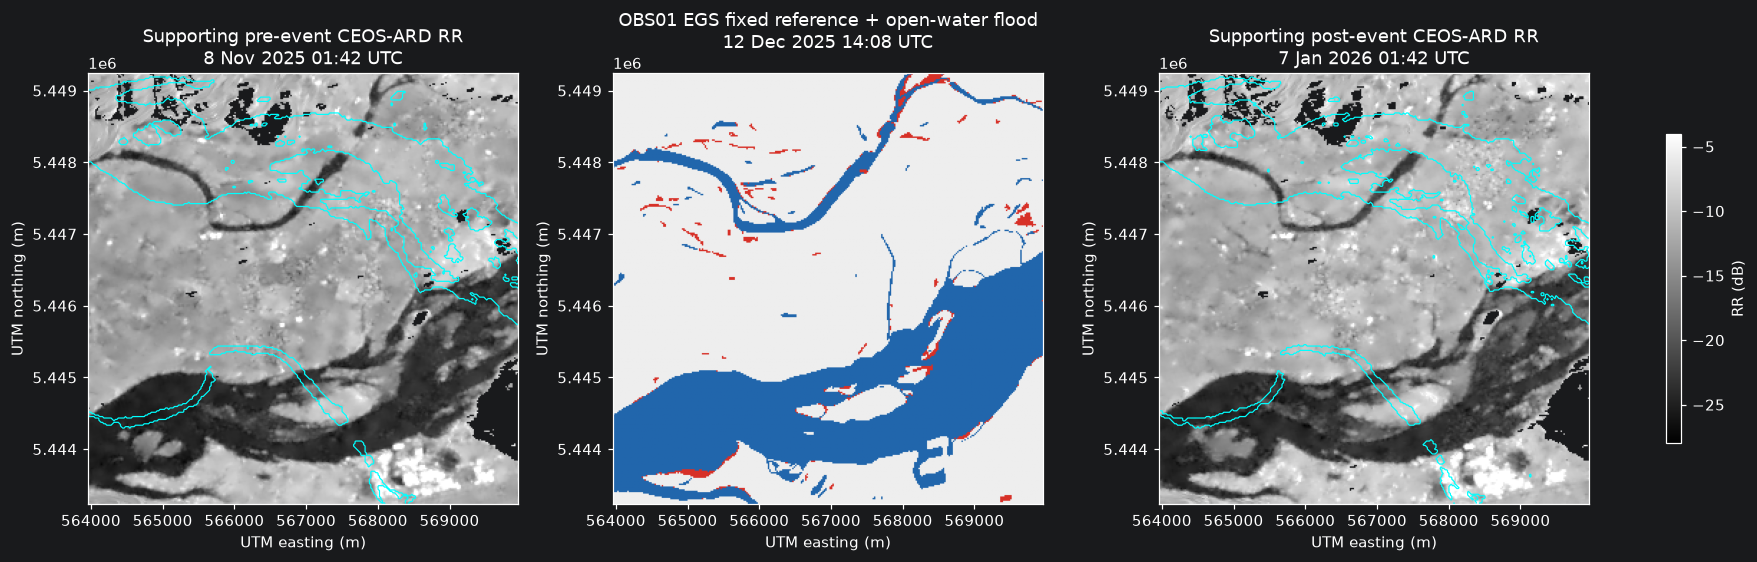

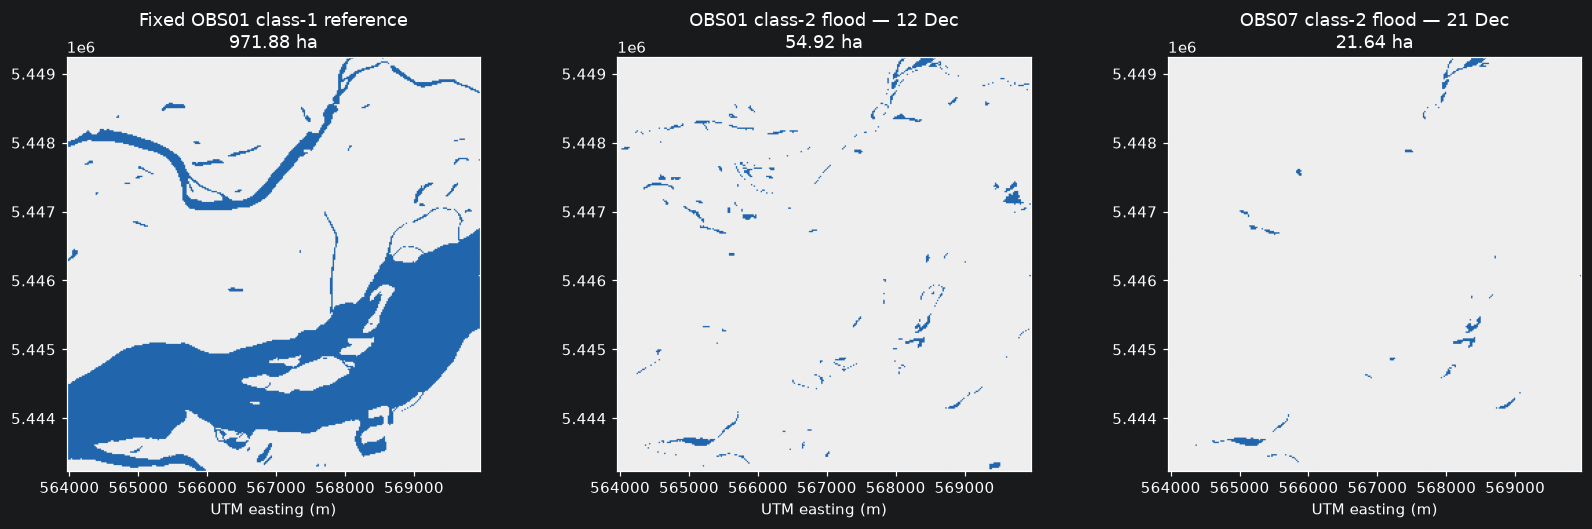

In [80]:
extent = (TARGET_BOUNDS[0], TARGET_BOUNDS[2], TARGET_BOUNDS[1], TARGET_BOUNDS[3])

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
pre_rr = np.ma.masked_invalid(ard_scenes["pre-event"]["rr_db"])
post_rr = np.ma.masked_invalid(ard_scenes["post-event"]["rr_db"])
im = axes[0].imshow(pre_rr, cmap="gray", vmin=-28, vmax=-4, extent=extent)
axes[0].contour(ard_scenes["pre-event"]["water"], levels=[0.5], colors="#00ffff", linewidths=0.8, extent=extent)
axes[0].set_title("Supporting pre-event CEOS-ARD RR\n8 Nov 2025 01:42 UTC")
event_class = np.zeros(TARGET_SHAPE, dtype=np.uint8)
event_class[fixed_reference] = 1
event_class[event_gain] = 2
axes[1].imshow(event_class, cmap=ListedColormap(["#eeeeee", "#2166ac", "#d73027"]), vmin=0, vmax=2, extent=extent)
axes[1].set_title("OBS01 EGS fixed reference + open-water flood\n12 Dec 2025 14:08 UTC")
axes[2].imshow(post_rr, cmap="gray", vmin=-28, vmax=-4, extent=extent)
axes[2].contour(ard_scenes["post-event"]["water"], levels=[0.5], colors="#00ffff", linewidths=0.8, extent=extent)
axes[2].set_title("Supporting post-event CEOS-ARD RR\n7 Jan 2026 01:42 UTC")
for ax in axes:
    ax.set_xlabel("UTM easting (m)")
    ax.set_ylabel("UTM northing (m)")
fig.colorbar(im, ax=[axes[0], axes[2]], shrink=0.72, label="RR (dB)")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.7), constrained_layout=True)
for ax, label, mask in zip(
    axes,
    ["Fixed OBS01 class-1 reference", "OBS01 class-2 flood — 12 Dec", "OBS07 class-2 flood — 21 Dec"],
    [fixed_reference, egs_scenes["OBS01"]["flood"], egs_scenes["OBS07"]["flood"]],
):
    shown = np.where(all_egs_valid, mask.astype(float), np.nan)
    ax.imshow(shown, cmap=ListedColormap(["#eeeeee", "#2166ac"]), vmin=0, vmax=1, extent=extent)
    ax.set_title(f"{label}\n{mask.sum()*PIXEL_AREA_HA:.2f} ha")
    ax.set_xlabel("UTM easting (m)")
plt.show()

## 14. Fixed-reference change-map construction

EGS class 1 is **Permanent Water** and class 2 is **Open Water Flood**. For comparable spatial accounting, the class-1 mask from OBS01 is held fixed across all seven acquisitions, while each acquisition contributes its own class-2 mask.

This fixed reference is an analysis convention—not a dated pre-event EGS observation, normal-water model, or hydrologic baseline. Raw per-product class-1 areas remain in the observation audit because the later products contain an approximately 1.40 ha production revision. The common 20 m grid standardizes spatial accounting but does not normalize sensor resolution, orbit, radiometry, channel, or independent EGS processing.

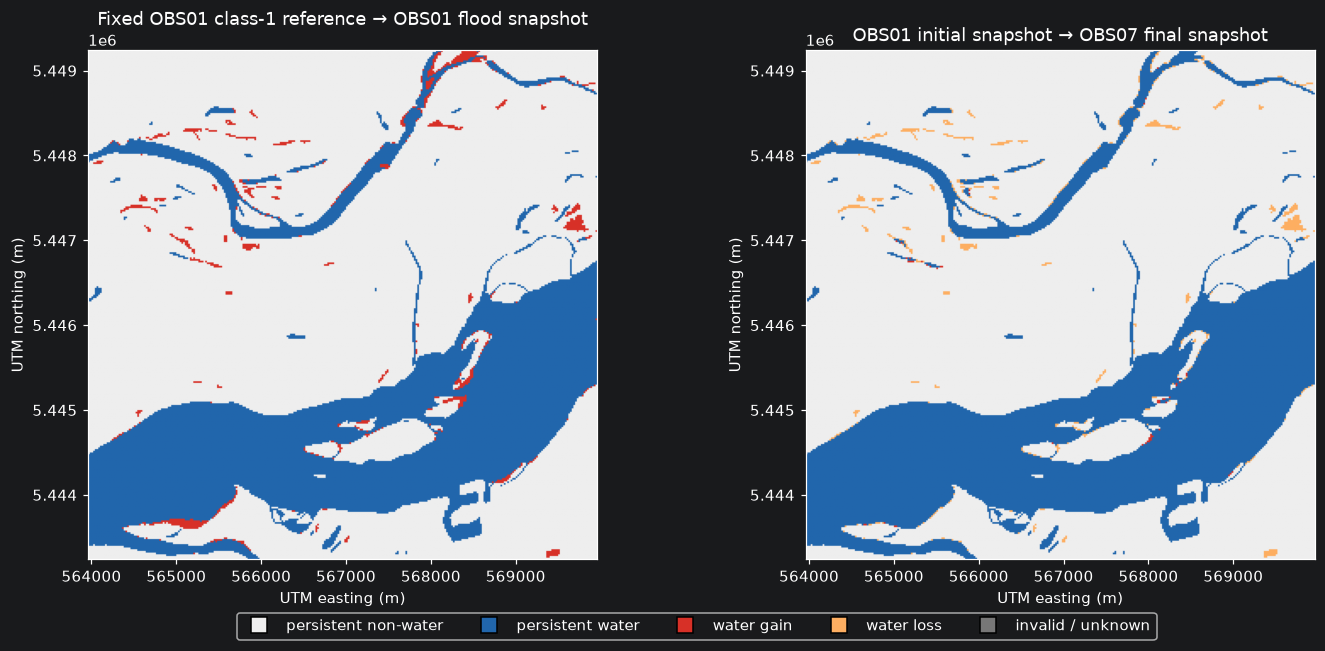

,comparison,new_or_final_only_ha,gross_recession_ha
0,fixed reference → OBS01,54.92,0.00
1,OBS01 → OBS07,2.16,35.44


In [81]:
def change_categories(before, after, valid):
    result = np.full(before.shape, 4, dtype=np.uint8)
    result[valid & ~before & ~after] = 0
    result[valid & before & after] = 1
    result[valid & ~before & after] = 2
    result[valid & before & ~after] = 3
    return result

reference_to_initial = change_categories(pre_water, event_water, all_egs_valid)
initial_to_final = change_categories(event_water, post_water, all_egs_valid)
change_cmap = ListedColormap(["#eeeeee", "#2166ac", "#d73027", "#fdae61", "#777777"])
labels = ["persistent non-water", "persistent water", "water gain", "water loss", "invalid / unknown"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True)
axes[0].imshow(reference_to_initial, cmap=change_cmap, vmin=0, vmax=4, extent=extent)
axes[0].set_title("Fixed OBS01 class-1 reference → OBS01 flood snapshot")
axes[1].imshow(initial_to_final, cmap=change_cmap, vmin=0, vmax=4, extent=extent)
axes[1].set_title("OBS01 initial snapshot → OBS07 final snapshot")
for ax in axes:
    ax.set(xlabel="UTM easting (m)", ylabel="UTM northing (m)")
handles = [plt.Line2D([0], [0], marker="s", color="none", markerfacecolor=change_cmap(i), markersize=10, label=label)
           for i, label in enumerate(labels)]
fig.legend(handles=handles, loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.06))
plt.show()

change_summary = pd.DataFrame([
    ["fixed reference → OBS01", event_gain.sum()*PIXEL_AREA_HA, 0.0],
    ["OBS01 → OBS07", event_to_post_gain.sum()*PIXEL_AREA_HA, event_to_post_loss.sum()*PIXEL_AREA_HA],
], columns=["comparison", "new_or_final_only_ha", "gross_recession_ha"])
display(change_summary.round(2))

## 15. Acquisition-sequence audit

The plot connects seven discrete acquisitions in timestamp order only. It does not interpolate conditions between observations or identify a satellite-derived flood peak. The EGS open-water-flood class is the primary per-acquisition measurement; fixed-reference total mapped water is shown only as that class plus the unchanged OBS01 class-1 reference.

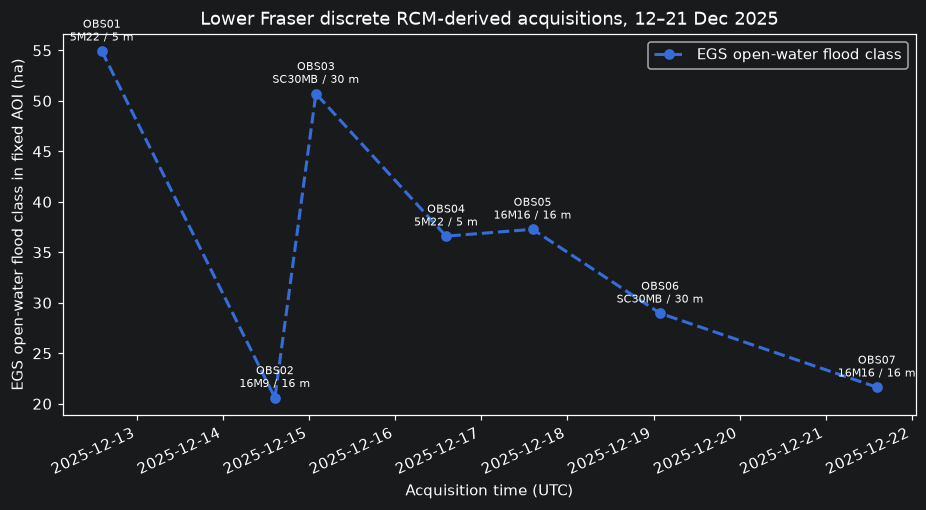

,observation_id,timestamp_utc,context_label,platform,beam_mode,source_resolution_m,orbit_direction,swath_radiometry,classifier_channel,raw_permanent_water_ha,fixed_reference_water_ha,egs_open_water_flood_ha,fixed_reference_total_water_ha,comparability_level
0,OBS01,2025-12-12 14:08:24+00:00,initial selected observation,RCM-1,5M22,5.0,DSC,Gamma,HH,971.88,971.88,54.92,1026.80,high within 5M22 pair
1,OBS02,2025-12-14 14:24:23+00:00,intervening low mapped extent,RCM-1,16M9,16.0,DSC,Gamma,HH,971.88,971.88,20.60,992.48,low: no same-beam comparison
2,OBS03,2025-12-15 01:50:37+00:00,secondary-pulse context,RCM-3,SC30MB,30.0,ASC,Gamma,HH,971.88,971.88,50.72,1022.60,limited: radiometry/channel differ within pair
3,OBS04,2025-12-16 14:08:35+00:00,later elevated observation,RCM-2,5M22,5.0,DSC,Gamma,HH,973.28,971.88,36.60,1008.48,high within 5M22 pair
4,OBS05,2025-12-17 14:16:34+00:00,later elevated observation,RCM-2,16M16,16.0,DSC,Sigma,HH,973.28,971.88,37.28,1009.16,high within 16M16 pair
5,OBS06,2025-12-19 01:50:14+00:00,lower endpoint observation,RCM-1,SC30MB,30.0,ASC,Sigma,HV,973.28,971.88,28.96,1000.84,limited: radiometry/channel differ within pair
6,OBS07,2025-12-21 14:16:46+00:00,lower endpoint observation,RCM-3,16M16,16.0,DSC,Sigma,HH,973.28,971.88,21.64,993.52,high within 16M16 pair


The raw class-1 step is product QA, not hydrologic change: [np.float64(971.88), np.float64(973.28)]


In [82]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(egs_df["timestamp_utc"], egs_df["egs_open_water_flood_ha"], marker="o", linewidth=2,
        linestyle="--", label="EGS open-water flood class")
for row in egs_df.itertuples():
    ax.annotate(f"{row.observation_id}\n{row.beam_mode} / {row.source_resolution_m:.0f} m",
                (row.timestamp_utc, row.egs_open_water_flood_ha), xytext=(0, 7),
                textcoords="offset points", ha="center", fontsize=7)
ax.set(title="Lower Fraser discrete RCM-derived acquisitions, 12–21 Dec 2025",
       xlabel="Acquisition time (UTC)", ylabel="EGS open-water flood class in fixed AOI (ha)")
ax.legend()
plt.xticks(rotation=25, ha="right")
plt.show()

audit_display = egs_df[[
    "observation_id", "timestamp_utc", "context_label", "platform", "beam_mode",
    "source_resolution_m", "orbit_direction", "swath_radiometry", "classifier_channel",
    "raw_permanent_water_ha", "fixed_reference_water_ha", "egs_open_water_flood_ha",
    "fixed_reference_total_water_ha", "comparability_level",
]].copy()
numeric_columns = audit_display.select_dtypes(include="number").columns
audit_display[numeric_columns] = audit_display[numeric_columns].round(3)
display(audit_display)

print("The raw class-1 step is product QA, not hydrologic change:",
      sorted(egs_df.raw_permanent_water_ha.round(2).unique()))

## 16. Grid-based change analysis

The 1 km grid contains 50 × 50 analysis pixels per full cell. It is large enough to damp individual shoreline pixels while remaining interpretable for local exposure screening. Boundary cells are retained with their exact valid denominator. The grid was chosen before viewing change magnitudes.

### Fixed semantic reference versus event observation

1. **Method/sensor benchmark:** Folly Lake describes observed variability of the validated workflow on a relatively stable control site. Its 5.88% maximum deviation is contextual evidence, not a universal flood threshold or a formal significance test.
2. **Fixed semantic reference:** a hydrologic normal would require multiple comparable pre-event observations for this fixed Lower Fraser AOI. That evidence is not available here. The notebook therefore fixes OBS01 EGS class 1 as a semantic analysis reference and labels each 1 km cell by its reference-water composition, without treating the reference as a pre-event normal or inventing probability cutoffs.
3. **Event anomaly:** the primary anomaly is EGS flood water appearing outside the fixed OBS01 permanent-water reference. Interpretation combines local deviation, spatial concentration/continuity, recession or persistence, independent EO/official agreement, and impact context. A cell being above the Folly Lake contextual value strengthens attention to it but does not by itself establish significance.

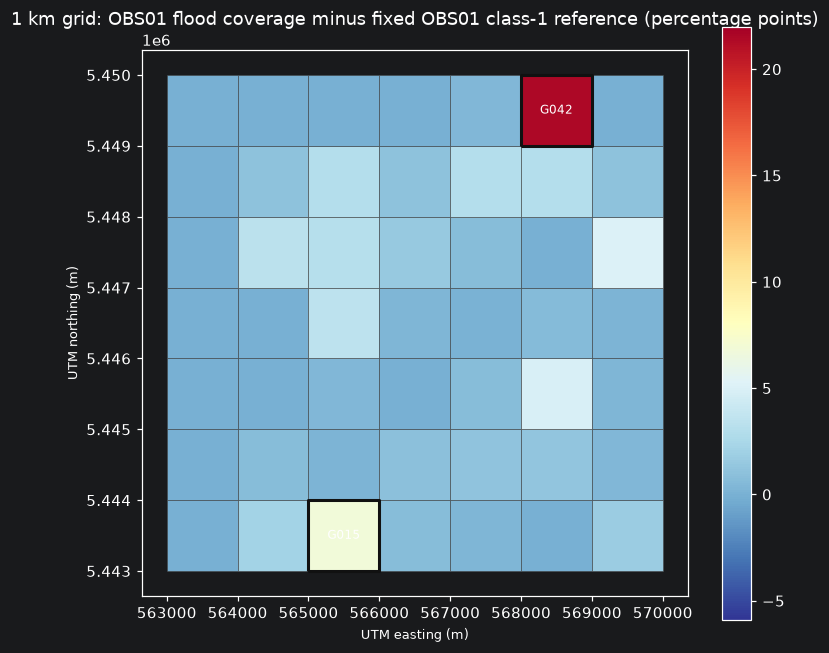

,grid_id,west,south,valid_pixels,valid_pct,pre_water_ratio_pct,event_water_ratio_pct,post_water_ratio_pct,event_minus_pre_pp,post_minus_pre_pp,event_gain_area_ha,event_to_post_loss_ha,above_control_context_5_88pp,baseline_interpretation,anomaly_interpretation,temporal_class
41,G042,568000.0,5449000.0,600,100.0,15.000,36.500,31.833,21.500,16.833,5.16,1.16,True,mixed fixed-reference water / non-reference area,localized gain above control-site context; corroboration required,recovery observed
14,G015,565000.0,5443000.0,1900,100.0,35.789,42.579,41.684,6.789,5.895,5.16,0.76,True,mixed fixed-reference water / non-reference area,localized gain above control-site context; corroboration required,recovery observed
46,G047,569000.0,5447000.0,2400,100.0,5.000,10.083,5.000,5.083,0.000,4.88,4.88,False,mixed fixed-reference water / non-reference area,mapped gain within control-site variation context,recovery observed
37,G038,568000.0,5445000.0,2500,100.0,74.520,79.360,78.560,4.840,4.040,4.84,1.36,False,mixed fixed-reference water / non-reference area,mapped gain within control-site variation context,recovery observed
17,G018,565000.0,5446000.0,2500,100.0,0.360,3.800,2.080,3.440,1.720,3.44,2.28,False,mixed fixed-reference water / non-reference area,mapped gain within control-site variation context,recovery observed
11,G012,564000.0,5447000.0,2500,100.0,2.080,5.360,2.080,3.280,0.000,3.28,3.28,False,mixed fixed-reference water / non-reference area,mapped gain within control-site variation context,recovery observed
18,G019,565000.0,5447000.0,2500,100.0,21.520,24.600,22.200,3.080,0.680,3.08,2.48,False,mixed fixed-reference water / non-reference area,mapped gain within control-site variation context,recovery observed
19,G020,565000.0,5448000.0,2500,100.0,3.320,6.320,3.320,3.000,0.000,3.00,3.00,False,mixed fixed-reference water / non-reference area,mapped gain within control-site variation context,recovery observed
40,G041,568000.0,5448000.0,2500,100.0,2.960,5.960,3.440,3.000,0.480,3.00,2.52,False,mixed fixed-reference water / non-reference area,mapped gain within control-site variation context,recovery observed
33,G034,567000.0,5448000.0,2500,100.0,12.920,15.880,14.800,2.960,1.880,2.96,1.16,False,mixed fixed-reference water / non-reference area,mapped gain within control-site variation context,recovery observed


In [83]:
left, bottom, right, top = TARGET_BOUNDS
grid_rows = []
grid_id = 0
for x0 in np.arange(np.floor(left / GRID_METRES) * GRID_METRES, right, GRID_METRES):
    for y0 in np.arange(np.floor(bottom / GRID_METRES) * GRID_METRES, top, GRID_METRES):
        cell = box(x0, y0, x0 + GRID_METRES, y0 + GRID_METRES)
        cell_mask = geometry_mask([mapping(cell)], out_shape=TARGET_SHAPE,
                                  transform=TARGET_TRANSFORM, invert=True) & AOI_MASK
        valid = cell_mask & all_egs_valid
        if not valid.any():
            continue
        grid_id += 1
        pre_ratio = pre_water[valid].mean() * 100
        event_ratio = event_water[valid].mean() * 100
        post_ratio = post_water[valid].mean() * 100
        event_change = event_ratio - pre_ratio
        post_change = post_ratio - pre_ratio
        gain_area_ha = (event_gain & cell_mask).sum() * PIXEL_AREA_HA
        loss_to_post_ha = (event_to_post_loss & cell_mask).sum() * PIXEL_AREA_HA
        if np.isclose(pre_ratio, 0.0):
            baseline_interpretation = "no fixed-reference permanent water"
        elif np.isclose(pre_ratio, 100.0):
            baseline_interpretation = "entirely fixed-reference permanent water"
        else:
            baseline_interpretation = "mixed fixed-reference water / non-reference area"
        above_control_context = event_change > CONTROL_MAX_DEVIATION_PCT
        if gain_area_ha == 0:
            anomaly_interpretation = "no mapped event water gain"
        elif above_control_context:
            anomaly_interpretation = "localized gain above control-site context; corroboration required"
        else:
            anomaly_interpretation = "mapped gain within control-site variation context"
        if valid.sum() / cell_mask.sum() < 0.8:
            temporal = "unresolved"
        elif gain_area_ha > 0 and post_ratio < event_ratio:
            temporal = "recovery observed"
        elif gain_area_ha > 0 and post_ratio >= event_ratio:
            temporal = "persistent expansion"
        else:
            temporal = "no mapped event gain"
        grid_rows.append({
            "grid_id": f"G{grid_id:03d}", "west": x0, "south": y0,
            "valid_pixels": int(valid.sum()), "valid_pct": 100 * valid.sum() / cell_mask.sum(),
            "pre_water_ratio_pct": pre_ratio, "event_water_ratio_pct": event_ratio,
            "post_water_ratio_pct": post_ratio, "event_minus_pre_pp": event_change,
            "post_minus_pre_pp": post_change,
            "event_gain_area_ha": gain_area_ha,
            "event_to_post_loss_ha": loss_to_post_ha,
            "above_control_context_5_88pp": above_control_context,
            "baseline_interpretation": baseline_interpretation,
            "anomaly_interpretation": anomaly_interpretation,
            "temporal_class": temporal, "geometry": cell,
        })

grid_gdf = gpd.GeoDataFrame(grid_rows, geometry="geometry", crs=WORKING_CRS)
changed_cells = grid_gdf.loc[grid_gdf["above_control_context_5_88pp"]].copy()
fig, ax = plt.subplots(figsize=(8, 7))
grid_gdf.plot(column="event_minus_pre_pp", cmap="RdYlBu_r", vmin=-CONTROL_MAX_DEVIATION_PCT,
              vmax=max(22, grid_gdf.event_minus_pre_pp.max()), legend=True,
              edgecolor="#444", linewidth=0.35, ax=ax)
changed_cells.boundary.plot(color="#111", linewidth=2, ax=ax)
for row in changed_cells.itertuples():
    ax.annotate(row.grid_id, row.geometry.centroid.coords[0], ha="center", va="center", fontsize=8)
ax.set(title="1 km grid: OBS01 flood coverage minus fixed OBS01 class-1 reference (percentage points)",
       xlabel="UTM easting (m)", ylabel="UTM northing (m)")
plt.show()

grid_stats = grid_gdf.drop(columns="geometry").sort_values("event_minus_pre_pp", ascending=False)
display(grid_stats.round(3))

## 17. Measurement-noise comparison

In [84]:
pre_area = pre_water.sum() * PIXEL_AREA_HA
event_area = event_water.sum() * PIXEL_AREA_HA
post_area = post_water.sum() * PIXEL_AREA_HA
event_gain_ha = event_gain.sum() * PIXEL_AREA_HA
relative_gain_pct = 100 * event_gain_ha / pre_area
control_median_ha = 70.76
control_max_abs_ha = control_median_ha * CONTROL_MAX_DEVIATION_PCT / 100

noise_table = pd.DataFrame([
    ["Folly Lake coefficient of variation", CONTROL_CV_PCT, "Empirical descriptive context only"],
    ["Folly Lake largest single-date deviation", CONTROL_MAX_DEVIATION_PCT, f"≈ {control_max_abs_ha:.2f} ha at the 70.76 ha median"],
    ["Folly Lake same-day RCM/S2 area difference", CONTROL_S2_AREA_DIFFERENCE_PCT, "Cross-sensor area benchmark"],
    ["Event AOI total relative water gain", relative_gain_pct, f"{event_gain_ha:.2f} ha; {event_gain_ha/control_max_abs_ha:.1f}× the control absolute deviation"],
    ["Largest local 1 km-grid increase", grid_gdf.event_minus_pre_pp.max(), "Local percentage-point signal"],
], columns=["measure", "percent / percentage points", "interpretation"])
display(noise_table.round(3))
print(f"Cells above the 5.88 pp control-site context: {len(changed_cells)} / {len(grid_gdf)}; gain inside them: {changed_cells.event_gain_area_ha.sum():.2f} ha")
print("Conclusion: these are contextual comparisons, not a universal threshold or a formal significance test. The local anomaly interpretation also requires spatial, temporal, independent-source, and impact evidence.")

,measure,percent / percentage points,interpretation
0,Folly Lake coefficient of variation,3.200,Empirical descriptive context only
1,Folly Lake largest single-date deviation,5.880,≈ 4.16 ha at the 70.76 ha median
2,Folly Lake same-day RCM/S2 area difference,4.880,Cross-sensor area benchmark
3,Event AOI total relative water gain,5.651,54.92 ha; 13.2× the control absolute deviation
4,Largest local 1 km-grid increase,21.500,Local percentage-point signal


Cells above the 5.88 pp control-site context: 2 / 49; gain inside them: 10.32 ha
Conclusion: these are contextual comparisons, not a universal threshold or a formal significance test. The local anomaly interpretation also requires spatial, temporal, independent-source, and impact evidence.


## 18. Multi-source agreement

,comparison,valid_pixels,TP,FP,FN,TN,precision,recall,F1,IoU,RCM_area_ha,S2_area_ha,area_difference_ha
0,RCM 21 Dec recovery water vs S2 27 Dec NDWI,88515,15774,8017,357,64367,0.663,0.978,0.79,0.653,951.64,645.24,306.4


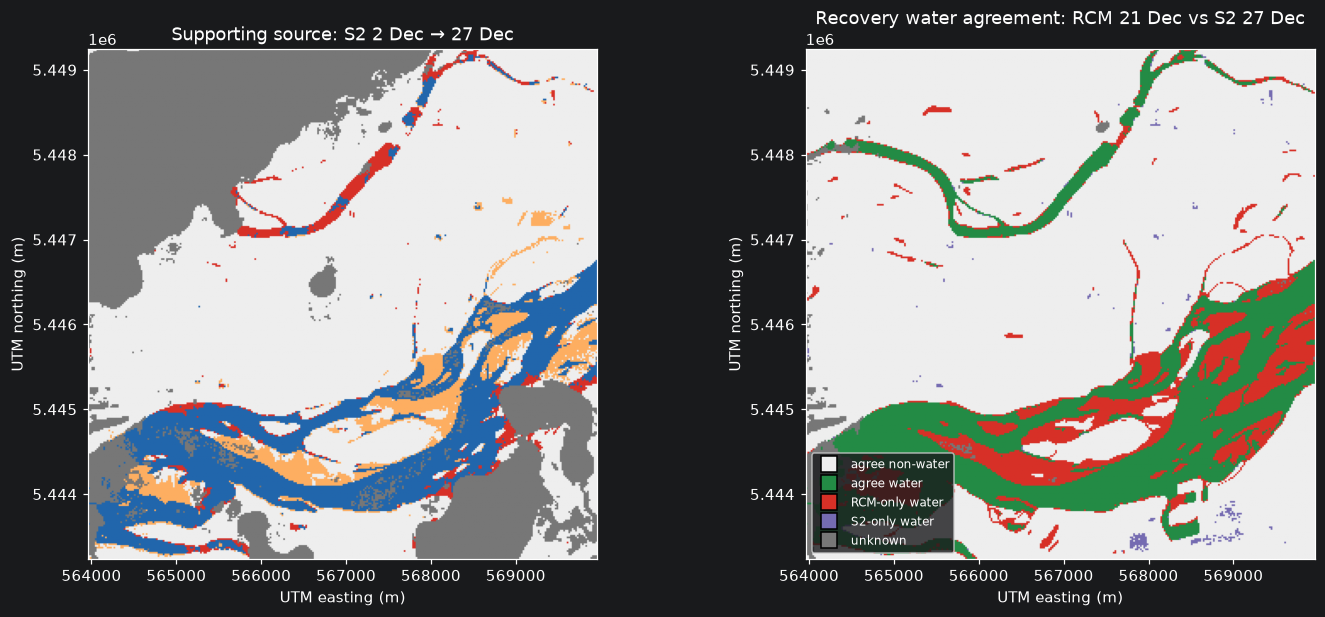

Likely disagreement drivers: 6.2-day timing offset, water recession, optical/SAR physics, cloud/SCL masking, resolution, and mixed shoreline pixels.


In [85]:
def agreement_metrics(prediction, reference, valid, label):
    pred = prediction[valid].astype(bool)
    ref = reference[valid].astype(bool)
    tp = int(np.sum(pred & ref)); fp = int(np.sum(pred & ~ref))
    fn = int(np.sum(~pred & ref)); tn = int(np.sum(~pred & ~ref))
    precision = tp / (tp + fp) if tp + fp else np.nan
    recall = tp / (tp + fn) if tp + fn else np.nan
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else np.nan
    iou = tp / (tp + fp + fn) if tp + fp + fn else np.nan
    return {
        "comparison": label, "valid_pixels": int(valid.sum()), "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "precision": precision, "recall": recall, "F1": f1, "IoU": iou,
        "RCM_area_ha": pred.sum() * PIXEL_AREA_HA, "S2_area_ha": ref.sum() * PIXEL_AREA_HA,
        "area_difference_ha": (pred.sum() - ref.sum()) * PIXEL_AREA_HA,
    }

recovery_common = all_egs_valid & s2_scenes["recovery-period"]["valid"]
agreement = agreement_metrics(post_water, s2_scenes["recovery-period"]["water"], recovery_common,
                              "RCM 21 Dec recovery water vs S2 27 Dec NDWI")
display(pd.DataFrame([agreement]).round(3))

# 0 both non-water, 1 agree water, 2 RCM-only, 3 S2-only, 4 unknown
agreement_map = np.full(TARGET_SHAPE, 4, dtype=np.uint8)
agreement_map[recovery_common & ~post_water & ~s2_scenes["recovery-period"]["water"]] = 0
agreement_map[recovery_common & post_water & s2_scenes["recovery-period"]["water"]] = 1
agreement_map[recovery_common & post_water & ~s2_scenes["recovery-period"]["water"]] = 2
agreement_map[recovery_common & ~post_water & s2_scenes["recovery-period"]["water"]] = 3
agreement_cmap = ListedColormap(["#eeeeee", "#238b45", "#d73027", "#756bb1", "#777777"])
agreement_labels = ["agree non-water", "agree water", "RCM-only water", "S2-only water", "unknown"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True)
s2_change = change_categories(s2_scenes["pre-event"]["water"], s2_scenes["recovery-period"]["water"], s2_common)
axes[0].imshow(s2_change, cmap=change_cmap, vmin=0, vmax=4, extent=extent)
axes[0].set_title("Supporting source: S2 2 Dec → 27 Dec")
axes[1].imshow(agreement_map, cmap=agreement_cmap, vmin=0, vmax=4, extent=extent)
axes[1].set_title("Recovery water agreement: RCM 21 Dec vs S2 27 Dec")
for ax in axes:
    ax.set(xlabel="UTM easting (m)", ylabel="UTM northing (m)")
handles = [plt.Line2D([0], [0], marker="s", color="none", markerfacecolor=agreement_cmap(i), markersize=10, label=label)
           for i, label in enumerate(agreement_labels)]
axes[1].legend(handles=handles, loc="lower left", fontsize=8)
plt.show()

print("Likely disagreement drivers: 6.2-day timing offset, water recession, optical/SAR physics, cloud/SCL masking, resolution, and mixed shoreline pixels.")

## 19. Event interpretation: variable acquisitions with a lower final endpoint

In [86]:
temporal_counts = grid_gdf["temporal_class"].value_counts().rename_axis("temporal_class").reset_index(name="grid_cells")
display(temporal_counts)

initial_flood_ha = egs_df.iloc[0].egs_open_water_flood_ha
final_flood_ha = egs_df.iloc[-1].egs_open_water_flood_ha
persistent_ha = (egs_scenes["OBS01"]["flood"] & egs_scenes["OBS07"]["flood"] & all_egs_valid).sum() * PIXEL_AREA_HA
gross_recession_ha = event_to_post_loss.sum() * PIXEL_AREA_HA
final_only_ha = event_to_post_gain.sum() * PIXEL_AREA_HA
net_endpoint_decline_ha = initial_flood_ha - final_flood_ha

endpoint_metrics = pd.DataFrame([
    ("Initial-observation open-water flood extent", initial_flood_ha),
    ("Persistent initial-observation flood", persistent_ha),
    ("Gross recession from initial footprint", gross_recession_ha),
    ("Final-observation flood outside initial footprint", final_only_ha),
    ("Net endpoint decline", net_endpoint_decline_ha),
], columns=["metric", "area_ha"])
display(endpoint_metrics.round(2))

assert np.isclose(initial_flood_ha, persistent_ha + gross_recession_ha)
assert np.isclose(final_flood_ha, persistent_ha + final_only_ha)
assert np.isclose(net_endpoint_decline_ha, gross_recession_ha - final_only_ha)

display(Markdown(
    "**Event-level interpretation:** the final mapped extent is lower than the initial selected observation, "
    "following a variable acquisition sequence with localized persistence and redistribution. The sequence is "
    "not monotonic and does not identify a satellite-derived flood peak."
))

,temporal_class,grid_cells
0,recovery observed,32
1,no mapped event gain,16
2,persistent expansion,1


,metric,area_ha
0,Initial-observation open-water flood extent,54.92
1,Persistent initial-observation flood,19.48
2,Gross recession from initial footprint,35.44
3,Final-observation flood outside initial footprint,2.16
4,Net endpoint decline,33.28


**Event-level interpretation:** the final mapped extent is lower than the initial selected observation, following a variable acquisition sequence with localized persistence and redistribution. The sequence is not monotonic and does not identify a satellite-derived flood peak.

## 20. Initial impact-overlay analysis

Road geometry is fetched from the OpenStreetMap Overpass API and intersected with the near-event water-gain raster polygon. Results describe geometric **intersection / potential exposure only**. They do not prove closure, damage, traffic impact, or flood depth. Wider official reports (including Highway 1 impacts) provide event context but are not assigned to this compact AOI unless the geometries intersect it.

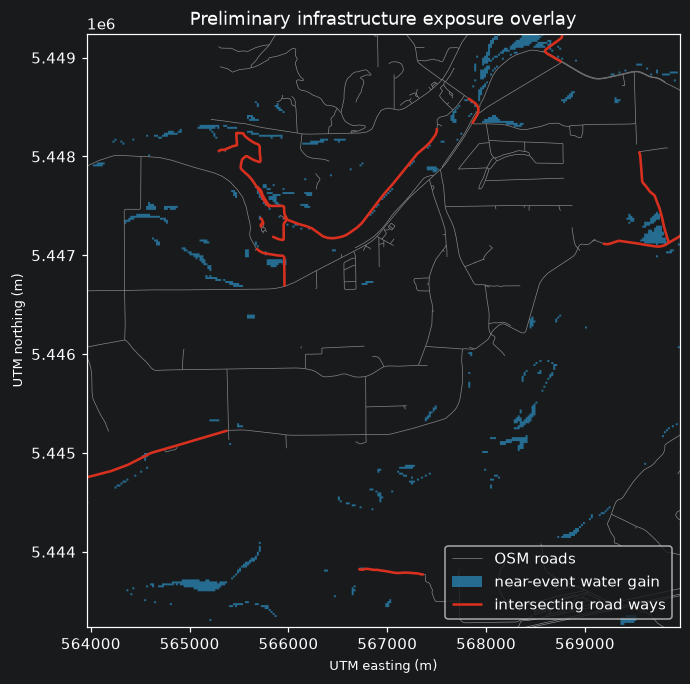

,OSM_road_ways_in_AOI,ways_intersecting_water_gain,intersection_length_km,bridge_ways_intersecting,bridge_intersection_length_m,Highway_1_ways_intersecting_in_AOI
0,238,14,0.346,1,8.717,0


,osm_id,highway,name,ref,bridge,flood_intersection_m
106,576124615,track,Nicomen Island Dyke,NaN,NaN,76.77
74,35501431,track,Dyke Road,NaN,NaN,47.15
41,35499368,residential,Ross Road,NaN,NaN,40.00
183,1416643899,track,NaN,NaN,NaN,40.00
180,1394094237,path,NaN,NaN,NaN,36.43
98,502175282,primary,Lougheed Highway,BC 7,NaN,32.62
46,35499471,residential,Nicomen Slough Road,NaN,NaN,20.38
129,1346293505,track,NaN,NaN,NaN,14.74
165,1353553405,track,NaN,NaN,NaN,13.06
85,62001004,primary,Lougheed Highway,BC 7,yes,8.72


In [87]:
def overpass_roads(bbox):
    west, south, east, north = bbox
    query = f'[out:json][timeout:90];way["highway"]({south},{west},{north},{east});out tags geom;'
    payload = None
    for endpoint in [
        "https://overpass-api.de/api/interpreter",
        "https://overpass.kumi.systems/api/interpreter",
        "https://overpass.private.coffee/api/interpreter",
    ]:
        try:
            request = Request(endpoint + "?" + urlencode({"data": query}),
                              headers={"User-Agent": "earth-in-motion-hackathon/1.0"})
            with urlopen(request, timeout=75) as response:
                payload = json.load(response)
            break
        except Exception as exc:
            print("Overpass endpoint failed:", endpoint, type(exc).__name__)
    if payload is None:
        raise RuntimeError("No Overpass endpoint returned road data")
    records = []
    for element in payload.get("elements", []):
        coords = [(node["lon"], node["lat"]) for node in element.get("geometry", [])]
        if len(coords) < 2:
            continue
        tags = element.get("tags", {})
        records.append({
            "osm_id": element["id"], "highway": tags.get("highway"), "name": tags.get("name"),
            "ref": tags.get("ref"), "bridge": tags.get("bridge"), "geometry": LineString(coords),
        })
    return gpd.GeoDataFrame(records, geometry="geometry", crs=4326)

gain_geometries = [shape(geom) for geom, value in shapes(
    event_gain.astype(np.uint8), mask=event_gain, transform=TARGET_TRANSFORM) if value == 1]
gain_geometry = unary_union(gain_geometries)
roads = overpass_roads(AOI_BBOX).to_crs(WORKING_CRS)
roads["flood_intersection_m"] = roads.geometry.intersection(gain_geometry).length
potentially_exposed = roads.loc[roads["flood_intersection_m"] > 0].copy()
bridges = potentially_exposed.loc[
    potentially_exposed["bridge"].notna() & ~potentially_exposed["bridge"].isin(["no", "false"])]
highway1 = potentially_exposed.loc[
    potentially_exposed["ref"].fillna("").str.contains(r"(?:^|;)1(?:$|;)", regex=True)]

fig, ax = plt.subplots(figsize=(8, 7))
roads.plot(ax=ax, color="#888", linewidth=0.45, label="OSM roads")
gpd.GeoSeries([gain_geometry], crs=WORKING_CRS).plot(ax=ax, color="#2b8cbe", alpha=0.72, label="near-event water gain")
potentially_exposed.plot(ax=ax, color="#d7301f", linewidth=1.7, label="intersecting road ways")
ax.set(xlim=(left, right), ylim=(bottom, top), title="Preliminary infrastructure exposure overlay",
       xlabel="UTM easting (m)", ylabel="UTM northing (m)")
ax.legend(loc="lower right")
plt.show()

impact_summary = pd.DataFrame([{
    "OSM_road_ways_in_AOI": len(roads),
    "ways_intersecting_water_gain": len(potentially_exposed),
    "intersection_length_km": potentially_exposed.flood_intersection_m.sum() / 1000,
    "bridge_ways_intersecting": len(bridges),
    "bridge_intersection_length_m": bridges.flood_intersection_m.sum(),
    "Highway_1_ways_intersecting_in_AOI": len(highway1),
}])
display(impact_summary.round(3))
display(potentially_exposed[["osm_id", "highway", "name", "ref", "bridge", "flood_intersection_m"]]
        .sort_values("flood_intersection_m", ascending=False).round(2))

## 21. Findings

In [88]:
findings = f'''
### Evidence-backed findings

1. All seven EGS acquisitions have **{all_egs_valid.mean()*100:.1f}% common valid coverage** on the fixed 20 m accounting grid.
2. OBS01 maps **{initial_flood_ha:.2f} ha** of EGS open-water flood outside the fixed OBS01 class-1 reference; OBS07 maps **{final_flood_ha:.2f} ha**.
3. The endpoint transition contains **{gross_recession_ha:.2f} ha gross recession**, **{persistent_ha:.2f} ha persistence**, and **{final_only_ha:.2f} ha final-only mapping**, producing a **{net_endpoint_decline_ha:.2f} ha net decline**.
4. The OBS02→OBS03 jump is interpreted as mixed hydrologic and observational change: official regional gauges rise during 14–17 Dec, while beam, resolution and orbit change and spatial Jaccard is low.
5. **{len(changed_cells)} of {len(grid_gdf)}** 1 km cells exceed the Folly Lake 5.88 pp empirical context. This is not a universal threshold or significance decision.
6. Recovery-period RCM/Sentinel-2 agreement is **IoU {agreement['IoU']:.3f}, F1 {agreement['F1']:.3f}**, with a 6.2-day offset.
7. The OBS01 snapshot intersects **{len(potentially_exposed)} OSM road ways** over **{potentially_exposed.flood_intersection_m.sum()/1000:.3f} km**, including **{len(bridges)} bridge-tagged way**. These are potential exposures, not confirmed damage.
'''
display(Markdown(findings))


### Evidence-backed findings

1. All seven EGS acquisitions have **100.0% common valid coverage** on the fixed 20 m accounting grid.
2. OBS01 maps **54.92 ha** of EGS open-water flood outside the fixed OBS01 class-1 reference; OBS07 maps **21.64 ha**.
3. The endpoint transition contains **35.44 ha gross recession**, **19.48 ha persistence**, and **2.16 ha final-only mapping**, producing a **33.28 ha net decline**.
4. The OBS02→OBS03 jump is interpreted as mixed hydrologic and observational change: official regional gauges rise during 14–17 Dec, while beam, resolution and orbit change and spatial Jaccard is low.
5. **2 of 49** 1 km cells exceed the Folly Lake 5.88 pp empirical context. This is not a universal threshold or significance decision.
6. Recovery-period RCM/Sentinel-2 agreement is **IoU 0.653, F1 0.790**, with a 6.2-day offset.
7. The OBS01 snapshot intersects **14 OSM road ways** over **0.346 km**, including **1 bridge-tagged way**. These are potential exposures, not confirmed damage.


## 22. Limitations

- Every EGS product was processed independently and reports **Moderate** confidence. The sequence mixes 5, 16 and 30 m source resolutions, beam modes, ascending/descending views, Gamma/Sigma representations and HH/HV classifier channels.
- Rasterization to 20 m standardizes spatial accounting but does not normalize sensor or product response. No empirical correction factor is applied.
- The OBS01 class-1 mask is a fixed semantic analysis reference, not an independently observed pre-event normal-water surface or multi-date frequency model.
- Raw class-1 area changes from 971.88 to 973.28 ha between product groups. This is retained as product QA and excluded from the comparable total-water calculation.
- The seven records are discrete acquisitions. Lines between them show sequence only; no daily interpolation or satellite-derived flood peak is claimed.
- The 14→15 Dec change has mixed hydrologic and observational causes. Available evidence cannot allocate a percentage to either cause.
- Mission and Chilliwack WaterOffice observations provide regional event context, not pixel-level validation. The preferred inside-AOI Cannor station lacks December 2025 daily values in the selected service.
- The fixed Phase 3 RR threshold applies only to the CEOS-ARD representation and is not transferred to EGS classes.
- The independent Sentinel-2 comparison is recovery-period only and has a 6.2-day offset.
- Folly Lake values are empirical method-variability context—not formal confidence limits, universal flood thresholds, or statistical significance tests.
- OSM, ALR and place overlays support potential-exposure/context statements only. They do not establish damage, crop loss, population exposure or climate attribution.

## 23. Recommendation for Phase 5

Proceed with the case using the new temporal contract rather than a hand-written trajectory. Preserve the seven acquisition timestamps and source metadata, the fixed OBS01 class-1 reference, the mixed-cause diagnosis for the 14→15 Dec jump, and separate gross recession (35.44 ha) from net endpoint decline (33.28 ha).

Phase 5 may retain the existing endpoint hotspot and potential-exposure geometries, but every exported artifact must identify its source observation and claim boundary. The dashboard must consume only small local derived outputs and must not convert the seven observations into a daily flood history.

## 24. Deterministic temporal-contract exports

The following exports are the Phase 4 source of truth for Phase 5. GeoJSON frames use the fixed 20 m analytical grid; no intermediate dates are synthesized.

In [89]:
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PHASE4_OUTPUT = REPO / "data" / "processed" / "phase4"
PHASE4_OUTPUT.mkdir(parents=True, exist_ok=True)

observation_columns = [
    "observation_id", "timestamp_utc", "context_label", "platform", "beam_mode",
    "source_resolution_m", "orbit_direction", "relative_orbit", "polarization_metadata",
    "swath_radiometry", "classifier_channel", "product_type", "product_version",
    "confidence", "valid_pixels", "valid_pct", "raw_permanent_water_ha",
    "fixed_reference_water_ha", "egs_open_water_flood_ha",
    "fixed_reference_total_water_ha", "comparability_group", "comparability_level",
    "source_product",
]
egs_df[observation_columns].to_csv(PHASE4_OUTPUT / "event_observations.csv", index=False)

def mask_to_geometry(mask):
    return unary_union([
        shape(geometry) for geometry, value in shapes(
            mask.astype(np.uint8), mask=mask, transform=TARGET_TRANSFORM
        ) if value == 1
    ])

frame_rows = []
for row in egs_df.itertuples():
    frame_rows.append({
        "observation_id": row.observation_id, "timestamp_utc": row.timestamp_utc.isoformat(),
        "context_label": row.context_label, "platform": row.platform, "beam_mode": row.beam_mode,
        "source_resolution_m": row.source_resolution_m, "orbit_direction": row.orbit_direction,
        "swath_radiometry": row.swath_radiometry, "classifier_channel": row.classifier_channel,
        "confidence": row.confidence, "geometry": mask_to_geometry(egs_scenes[row.observation_id]["flood"]),
    })
gpd.GeoDataFrame(frame_rows, geometry="geometry", crs=WORKING_CRS).to_file(
    PHASE4_OUTPUT / "egs_open_water_flood_frames.geojson", driver="GeoJSON"
)

gpd.GeoDataFrame([{
    "feature": "fixed_egs_permanent_water_reference",
    "reference_timestamp_utc": egs_df.iloc[0].timestamp_utc.isoformat(), "egs_class": 1,
    "semantic_role": "analysis reference; not an observed pre-event hydrologic normal",
    "area_ha": fixed_reference_ha, "geometry": mask_to_geometry(fixed_reference),
}], geometry="geometry", crs=WORKING_CRS).to_file(
    PHASE4_OUTPUT / "egs_permanent_water_reference.geojson", driver="GeoJSON"
)

transition_masks = {
    "persistent_initial_flood": egs_scenes["OBS01"]["flood"] & egs_scenes["OBS07"]["flood"],
    "gross_recession": egs_scenes["OBS01"]["flood"] & ~egs_scenes["OBS07"]["flood"],
    "recovery_only": ~egs_scenes["OBS01"]["flood"] & egs_scenes["OBS07"]["flood"],
}
transition_rows = [{
    "transition_class": key, "area_ha": value.sum() * PIXEL_AREA_HA,
    "initial_observation": "OBS01", "final_observation": "OBS07",
    "geometry": mask_to_geometry(value),
} for key, value in transition_masks.items()]
gpd.GeoDataFrame(transition_rows, geometry="geometry", crs=WORKING_CRS).to_file(
    PHASE4_OUTPUT / "endpoint_transition.geojson", driver="GeoJSON"
)

comparison_rows = []
for left, right in zip(egs_df.observation_id[:-1], egs_df.observation_id[1:]):
    before, after = egs_scenes[left]["flood"], egs_scenes[right]["flood"]
    overlap, lost, new, union = before & after, before & ~after, ~before & after, before | after
    comparison_rows.append({
        "from_observation": left, "to_observation": right,
        "overlap_ha": overlap.sum()*PIXEL_AREA_HA, "lost_ha": lost.sum()*PIXEL_AREA_HA,
        "new_ha": new.sum()*PIXEL_AREA_HA, "net_change_ha": (after.sum()-before.sum())*PIXEL_AREA_HA,
        "jaccard": overlap.sum()/union.sum(),
    })
pd.DataFrame(comparison_rows).to_csv(PHASE4_OUTPUT / "acquisition_comparisons.csv", index=False)

beam_pairs = []
for beam, left, right, caveat in [
    ("5M22", "OBS01", "OBS04", "Same beam/radiometry/channel; different platform/date."),
    ("SC30MB", "OBS03", "OBS06", "Gamma/HH changes to Sigma/HV; comparability remains limited."),
    ("16M16", "OBS05", "OBS07", "Same beam/radiometry/channel; different platform/date."),
]:
    before, after = egs_scenes[left]["flood"], egs_scenes[right]["flood"]
    overlap, union = before & after, before | after
    beam_pairs.append({
        "beam_mode": beam, "from_observation": left, "to_observation": right,
        "from_area_ha": before.sum()*PIXEL_AREA_HA, "to_area_ha": after.sum()*PIXEL_AREA_HA,
        "net_change_ha": (after.sum()-before.sum())*PIXEL_AREA_HA,
        "overlap_ha": overlap.sum()*PIXEL_AREA_HA, "jaccard": overlap.sum()/union.sum(),
        "caveat": caveat,
    })
pd.DataFrame(beam_pairs).to_csv(PHASE4_OUTPUT / "beam_family_comparisons.csv", index=False)

display(pd.DataFrame(comparison_rows).round(3))
display(pd.DataFrame(beam_pairs).round(3))
# The companion hydrograph is fetched only while rebuilding the scientific contract.
# The dashboard reads the committed local snapshot and never calls WaterOffice at startup.
WATEROFFICE_URL = (
    "https://wateroffice.ec.gc.ca/services/real_time_data/csv/inline?"
    "stations%5B%5D=08MH024&stations%5B%5D=08MH001&parameters%5B%5D=3&"
    "parameters%5B%5D=6&start_date=2025-12-12%2000%3A00%3A00&"
    "end_date=2025-12-22%2023%3A59%3A59"
)
hydro_raw = pd.read_csv(WATEROFFICE_URL)
hydro_raw.columns = [column.lstrip("\ufeff ") for column in hydro_raw.columns]
station_names = {
    "08MH001": "Chilliwack River at Vedder Crossing",
    "08MH024": "Fraser River at Mission",
}
station_distance_km = {"08MH001": 6.9, "08MH024": 41.8}
parameter_names = {3: ("water_level_daily_mean", "m"), 6: ("discharge_daily_mean", "m3/s")}
hydrology_rows = []
for row in hydro_raw.itertuples(index=False, name=None):
    record = dict(zip(hydro_raw.columns, row))
    parameter, unit = parameter_names[int(record["Parameter/Paramètre"])]
    station_id = record["ID"]
    hydrology_rows.append({
        "date": record["Date"], "station_id": station_id,
        "station_name": station_names[station_id], "parameter": parameter,
        "value": float(record["Value/Valeur"]), "unit": unit,
        "symbol": record["Symbol/Symbole"],
        "distance_to_aoi_km": station_distance_km[station_id],
        "context_role": "regional event context; not pixel-level validation",
        "source_url": WATEROFFICE_URL,
    })
pd.DataFrame(hydrology_rows).to_csv(PHASE4_OUTPUT / "event_hydrology.csv", index=False)

import hashlib

endpoint_metrics = {
    "initial_observation_open_water_flood": initial_flood_ha,
    "final_observation_open_water_flood": final_flood_ha,
    "persistent_initial_flood": persistent_ha,
    "gross_recession_from_initial_footprint": gross_recession_ha,
    "recovery_only": final_only_ha,
    "net_endpoint_decline": net_endpoint_decline_ha,
}
artifact_names = [
    "acquisition_comparisons.csv", "beam_family_comparisons.csv",
    "egs_open_water_flood_frames.geojson", "egs_permanent_water_reference.geojson",
    "endpoint_transition.geojson", "event_hydrology.csv", "event_observations.csv",
]
temporal_audit = {
    "schema_version": "2.0.0", "analysis_crs": WORKING_CRS,
    "aoi_bounds_utm": list(AOI_BOUNDS_UTM), "grid_resolution_m": PIXEL_SIZE,
    "observation_count": len(egs_df),
    "class_definitions": {
        "1": "EGS permanent water; fixed OBS01 class is used as the semantic analysis reference",
        "2": "EGS open-water flood directly mapped in each independently processed acquisition",
    },
    "fixed_reference_observation": "OBS01",
    "fixed_reference_timestamp_utc": egs_df.iloc[0].timestamp_utc.isoformat(),
    "comparability_policy": "The common 20 m grid standardizes spatial accounting but does not normalize source resolution, orbit, radiometry, channel, or independent EGS processing.",
    "diagnosis": "mixed_hydrologic_and_observational",
    "diagnosis_confidence": "medium-high that both factors exist; unresolved contribution ratio",
    "missing_fields": {
        "relative_orbit": "Unavailable in the supplied EGS Config XML; not inferred.",
        "incidence_angle": "Blank in the supplied EGS Config XML; not inferred.",
        "cannor_winter_data": "08MF038 is the preferred inside-AOI station but has no December 2025 daily series in the selected service response.",
    },
    "endpoint_metrics_ha": {key: round(value, 2) for key, value in endpoint_metrics.items()},
    "interpretation": "The seven records are discrete acquisitions, not a continuous hydrograph. Regional gauges support a secondary hydrologic pulse, while sensor/product differences materially limit attribution of the OBS02-to-OBS03 jump.",
    "source_artifact_sha256": {
        name: hashlib.sha256((PHASE4_OUTPUT / name).read_bytes()).hexdigest()
        for name in artifact_names
    },
}
(PHASE4_OUTPUT / "temporal_audit.json").write_text(json.dumps(temporal_audit, indent=2) + "\n")
print("Wrote the deterministic Phase 4 contract, including the dated WaterOffice snapshot and artifact hashes.")

,from_observation,to_observation,overlap_ha,lost_ha,new_ha,net_change_ha,jaccard
0,OBS01,OBS02,19.84,35.08,0.76,-34.32,0.356
1,OBS02,OBS03,11.20,9.40,39.52,30.12,0.186
2,OBS03,OBS04,16.64,34.08,19.96,-14.12,0.235
3,OBS04,OBS05,20.60,16.00,16.68,0.68,0.387
4,OBS05,OBS06,11.20,26.08,17.76,-8.32,0.203
5,OBS06,OBS07,11.20,17.76,10.44,-7.32,0.284


,beam_mode,from_observation,to_observation,from_area_ha,to_area_ha,net_change_ha,overlap_ha,jaccard,caveat
0,5M22,OBS01,OBS04,54.92,36.60,-18.32,26.44,0.406,Same beam/radiometry/channel; different platform/date.
1,SC30MB,OBS03,OBS06,50.72,28.96,-21.76,19.92,0.333,Gamma/HH changes to Sigma/HV; comparability remains limited.
2,16M16,OBS05,OBS07,37.28,21.64,-15.64,18.00,0.440,Same beam/radiometry/channel; different platform/date.


Wrote the deterministic Phase 4 contract, including the dated WaterOffice snapshot and artifact hashes.
